# ♟️ Chess Piece Detection with YOLOv11

Authors: Amith Koneru, Jackson Redman, Nick Petruccelli

This notebook documents the full report of the training and evaluation pipeline for detecting chess pieces using YOLOv11.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Change the path to where it is located in your google drive

%cd '/content/drive/MyDrive/Chess Project/notebook'

/content/drive/MyDrive/Chess Project/notebook


In [ ]:
# Install Ultralytics if needed
!pip install ultralytics

In [ ]:
from IPython.display import Image, display
from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
import os

## 1. Modeling

We used the **YOLOv11-small (YOLOv11s)** object detection architecture to recognize chess pieces from real-world images and videos.

### Architecture
- **Backbone:** Convolutional layers for feature extraction.
- **Neck:** PANet (Path Aggregation Network) /FPN-style (Feature Pyramid) layers for feature fusion.
- **Head:** Anchor-free detection head. Predicts objectness, class probabilities, and bounding box coordinates.

Architecture Image:

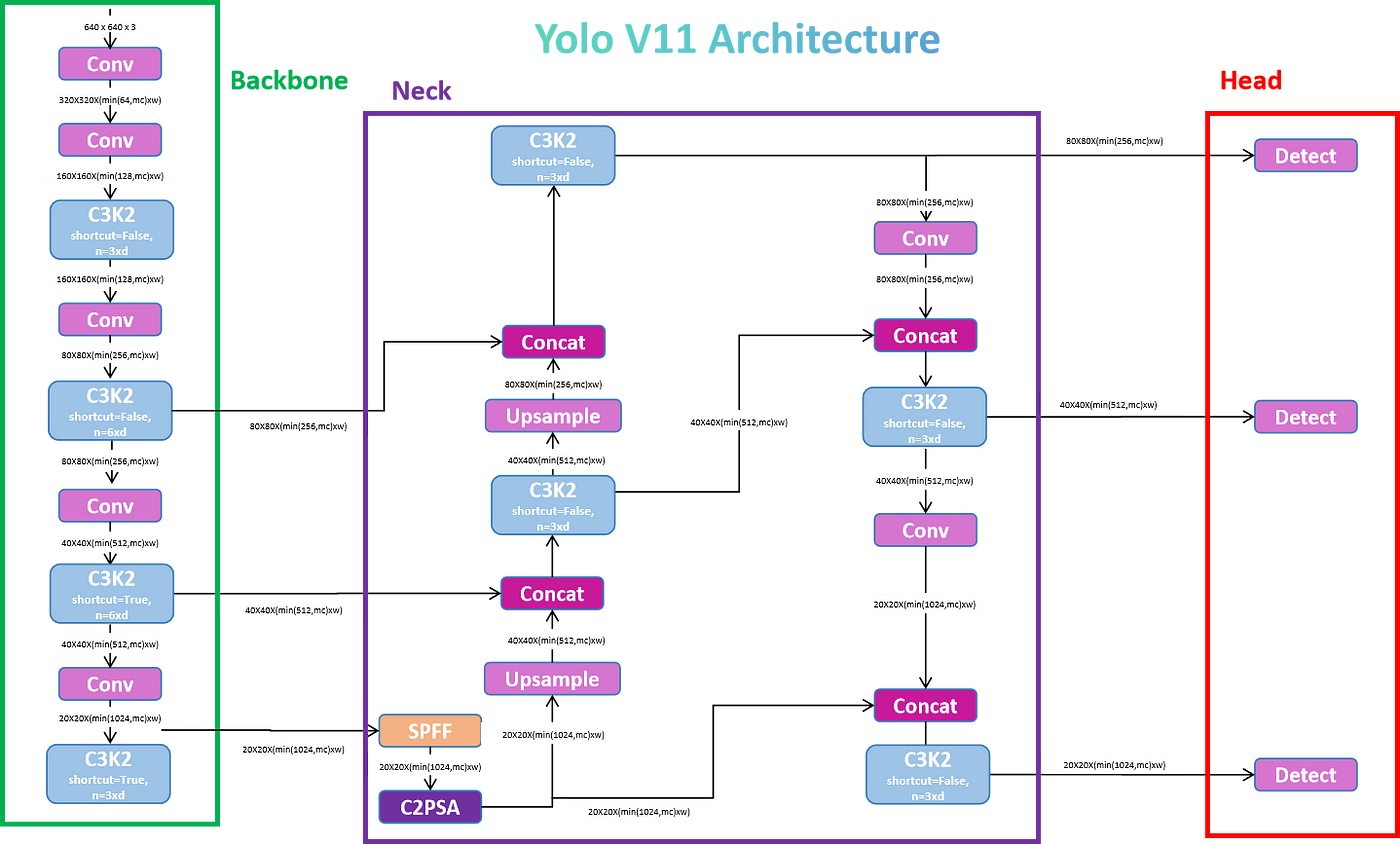

In [ ]:
display(Image('images/yolov11-architecture.png'))

### Loss Functions
- **Box Loss**: Measures how well the predicted bounding boxes match the ground truth boxes
- **Classification Loss**: Predicts correct class
- **Distribution Focal Loss (DFL)**: Improves bounding box regression

### Hyperparameters
- Model: `yolo11s.pt`
- Image Size: `640x640`
- Epochs: `100`
- Batch Size: `16`
- Optimizer: `AdamW`
- Learning Rate: `0.01`

## 2. Experimentation

To train and evaluate our YOLOv11-based chess detection model, we followed a structured experimental pipeline focused on data diversity, augmentation, and performance validation.

We combined three publicly available datasets for a total of 7,659 unique images:
- [Roboflow Chess Dataset](https://public.roboflow.com/object-detection/chess-full)
-[ChessReD2k Chess Dataset](https://data.4tu.nl/datasets/99b5c721-280b-450b-b058-b2900b69a90f/2)
-[OSFHome Synthetic Dataset](https://osf.io/xf3ka/)

To expand the dataset and increase robustness to camera angles and lighting, we applied the following offline augmentation for each image:
- Horizontal flip
- Vertical flip
- Rotation + Brightness/saturation adjustment

Resulting in a total of 30,636 images

### Dataset Split
- Train: `80%`
- Validation: `10%`
- Test: `10%`

### Libraries
- Ultralytics YOLO
- OpenCV
- Matplotlib

Initially, the Yolov11 model was trained only on the Roboflow and ChessReD datasets. The model's real-time performance was limited, as it occasionally failed to detect certain chess pieces entirely. Additionally, the model frequently misclassified certain pieces, confusing them with others of similar appearance.

To address these issues, we took two steps. First, we incorporated the OSFHome synthetic dataset, which more than doubled our image count, increasing visual diversity. Second, we applied offline data augmentation to simulate non-ideal conditions, such as variations in lighting, orientation, and color, to help the model generalize better during real-time inference.

### 2.1 Roboflow Dataset

The Roboflow dataset comprises 693 images of chessboards and various pieces. All photos were captured from a constant angle, with a tripod to the left of the board. The bounding boxes of all of the pieces are annotated as follows: white-king, white-queen, white-bishop, white-knight, white-rook, white-pawn, black-king, black-queen, black-bishop, black-knight, black-rook, black-pawn. The creators of this dataset took the images and created annotations in order to build their own chess piece detection model.

The data was already formatted for the YOLO model requirements, including bounding box locations for each class type in an image.

#### Example Images:

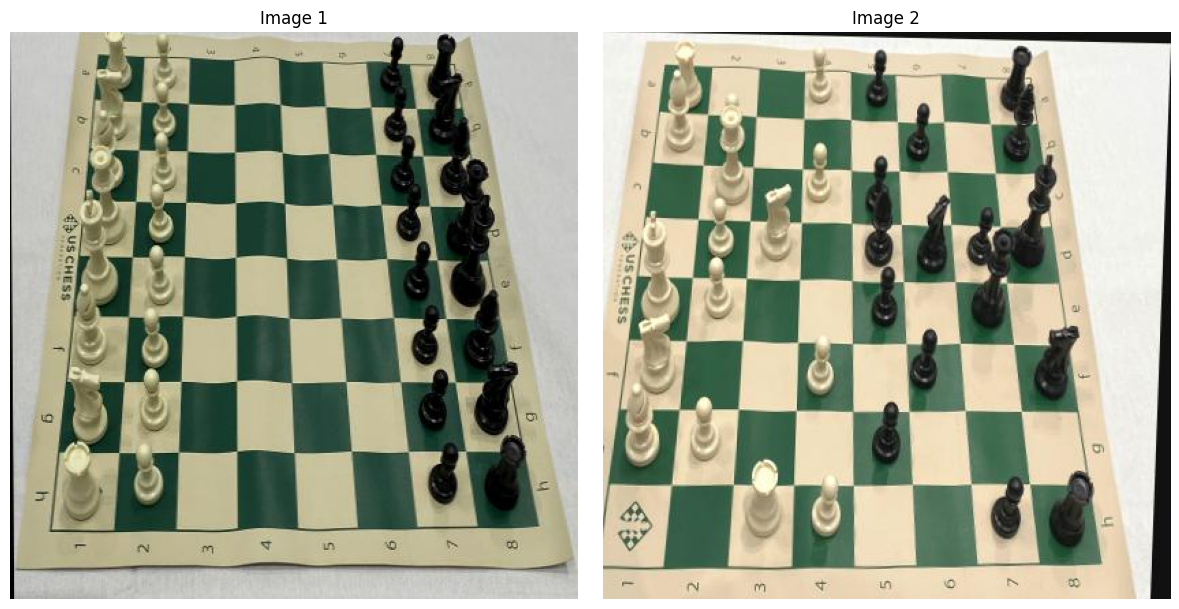

In [ ]:
roboflow_images = ['images/Roboflow/roboflow1.jpg',
                    'images/Roboflow/roboflow2.jpg']

n_images = len(roboflow_images)
cols = 2
rows = (n_images + cols - 1) // cols

plt.figure(figsize=(12, 6))

for i, img_path in enumerate(roboflow_images):
    img = mpimg.imread(img_path)
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.title(f"Image {i + 1}")
    plt.axis('off')

plt.tight_layout()
plt.show()

### 2.2 ChessReD Dataset
The Chess Recognition Dataset (ChessReD) comprises a diverse collection of 10,800 images of chess formations captured using smartphone cameras; a sensor choice made to ensure real-world applicability. It was collected by capturing images of chessboards with various chess piece configurations.

Three distinct smartphone models were used to capture the images. Each model has different camera specifications, such as resolution and sensor type, that introduce further variability in the dataset. The images were also taken from diverse angles, ranging from top-view to oblique angles, and from different player perspectives. These conditions simulate real-world scenarios where chessboards can be captured from a bystander's arbitrary point of view. Additionally, the dataset includes images captured under different lighting conditions, with both natural and artificial light sources.

The ChessReD2k is a subset of the ChessReD dataset that includes bounding box annotations for each piece on the board. We opted to select this subset due to the requirement of annotations to train the YOLOv11 model. ChessReD2k includes 2,708 images with bounding box annotations.

#### Example Images:

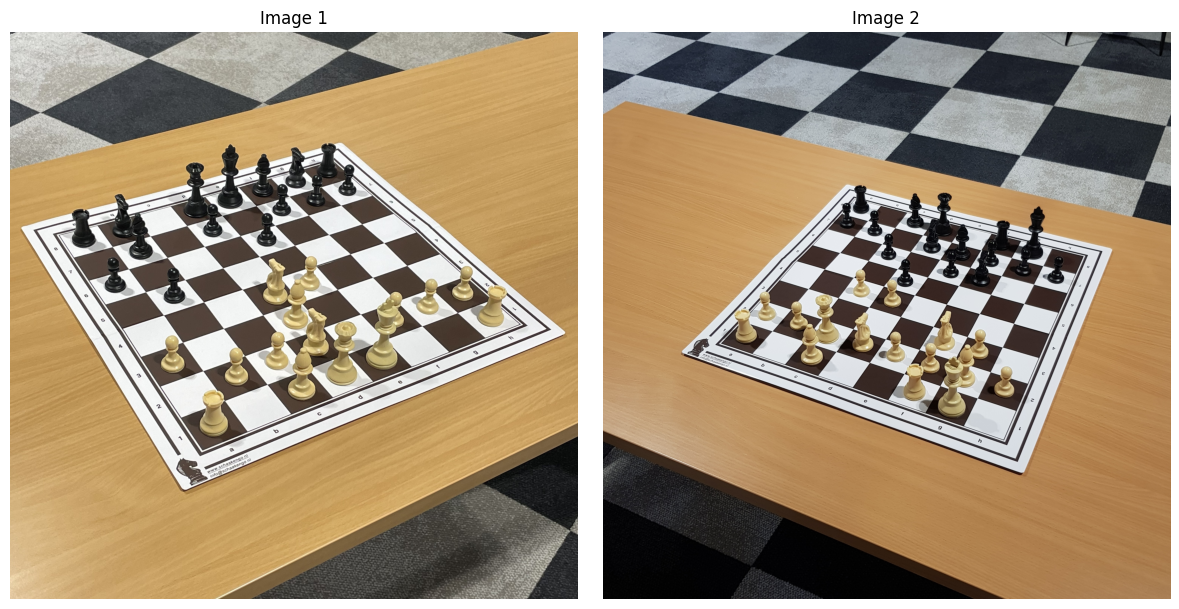

In [ ]:
chessReD_images = ['images/ChessReD/chessred1.jpg',
                    'images/ChessReD/chessred2.jpg']

n_images = len(chessReD_images)
cols = 2
rows = (n_images + cols - 1) // cols

plt.figure(figsize=(12, 6))

for i, img_path in enumerate(chessReD_images):
    img = mpimg.imread(img_path)
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.title(f"Image {i + 1}")
    plt.axis('off')

plt.tight_layout()
plt.show()

### 2.3 OSFHome Dataset
The OSFHome dataset contains 4,888 images of synthetic chessboards and pieces. The images were synthesized by randomly sampling 2% of all positions from a public dataset of 2851 games played by current World Chess Champion Magnus Carlsen. Accounting for duplicates, a total of 4,888 unique chess positions were obtained. In order to obtain realistic images of these chess positions, a 3D model of a chessboard set on a wooden table was created. The unique positions are rendered in an automated process, allowing for annotations to be exported, providing the pixel coordinates of the bounding boxes along with the class names.

The OSFHome dataset was the largest set out of the three to train the YOLOv11 model. As the board and pieces in this dataset contain different colors, it allows the model to predict with higher precision on different styles of chess boards.

#### Example Images:

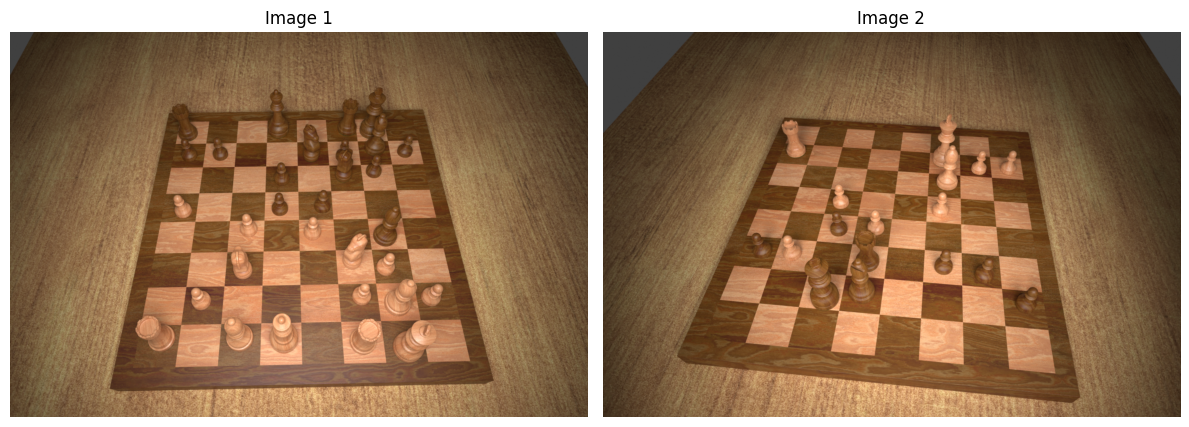

In [ ]:
osfhome_images = ['images/OSFHome/osfhome1.png',
                    'images/OSFHome/osfhome2.png']

n_images = len(osfhome_images)
cols = 2
rows = (n_images + cols - 1) // cols

plt.figure(figsize=(12, 6))

for i, img_path in enumerate(osfhome_images):
    img = mpimg.imread(img_path)
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.title(f"Image {i + 1}")
    plt.axis('off')

plt.tight_layout()
plt.show()

### 2.4 Dataset References

Masouris, A. (2023). Chess Recognition Dataset (ChessReD) (Version 2) [Data set]. 4TU.ResearchData. https://data.4tu.nl/datasets/99b5c721-280b-450b-b058-b2900b69a90f/2

Roboflow. (2021). Chess Pieces Dataset [Data set]. Roboflow Universe. https://public.roboflow.com/object-detection/chess-full

Wölflein, G., & Arandjelović, O. (2021). Dataset of Rendered Chess Game State Images [Data set]. OSF. https://osf.io/xf3ka/

## 3. Baseline

We chose YOLOv11s due to its speed and accuracy on small object detection. It improves over YOLOv8 with RepOptimizer and DFL loss, and performs well on low-resource GPUs. To detect many small chess pieces simultaneously in real-time, we needed a model capable of maintaining high accuracy given a sufficiently robust dataset.

**Methodology inspiration**:
1. [**End-To-End Chess Recognition**](https://arxiv.org/pdf/2310.04086) - Athanasios Masouris, Jan C. van Gemert

  While we adopted a different model methodology by utilizing YOLOv11, the core ideas from their research significantly influenced our project.
  - **Real-World-Data Emphasis**: The authors of the paper emphasized the importance of using diverse and realistic datasets, which led them to develop and utilize the ChessReD dataset. The ChessReD2k dataset accounted for over a quarter of our images and annotations.
  - **Handling of Visual Variability**: The dataset provided images of chessboards from various viewpoints, which the other two datasets could not account for. The authors focused on capturing images from various angles in order to generalize well across diverse scenarios.



2. [**Grid-Augmented Vision**](https://arxiv.org/pdf/2411.18270) - Joongwon Chae, Zhenyu Wang, Lian Zhang, Dongmei Yu, Peiwu Qin

  - **Piece Mapping**: One of the key challenges in achieving real-time chess piece detection was translating the model's bounding box outputs into a virtual representation of the chessboard. To solve this, we overlaid an 8x8 grid on top of the visual feed, with each cell corresponding to a specific rank and file on a standard chessboard. We determined that the most reliable point for mapping a piece's position was the bottom center of its bounding box. By comparing this point to the grid, we could infer which square the piece occupied. Although the grid itself was not provided to the model, this virtual segmentation approach, which was inspired by the Grid-Augmented Vision paper, allowed us to map detections to board positions effectively.

### 3.1 Methodology References



  Chae, J., Wang, Z., Zhang, L., Yu, D., & Qin, P. (2024). Grid-Augmented Vision: A Simple Yet Effective Approach for Enhanced Spatial Understanding in Multi-Modal Agents. arXiv. https://arxiv.org/abs/2411.18270

  Masouris, A., & van Gemert, J. C. (2023). End-to-End Chess Recognition. Computer Vision Lab, Delft University of Technology. arXiv preprint arXiv:2310.04086. https://arxiv.org/abs/2310.04086

## 4. Results

### 4.1 The following images correspond to the model peformance on the validation set:

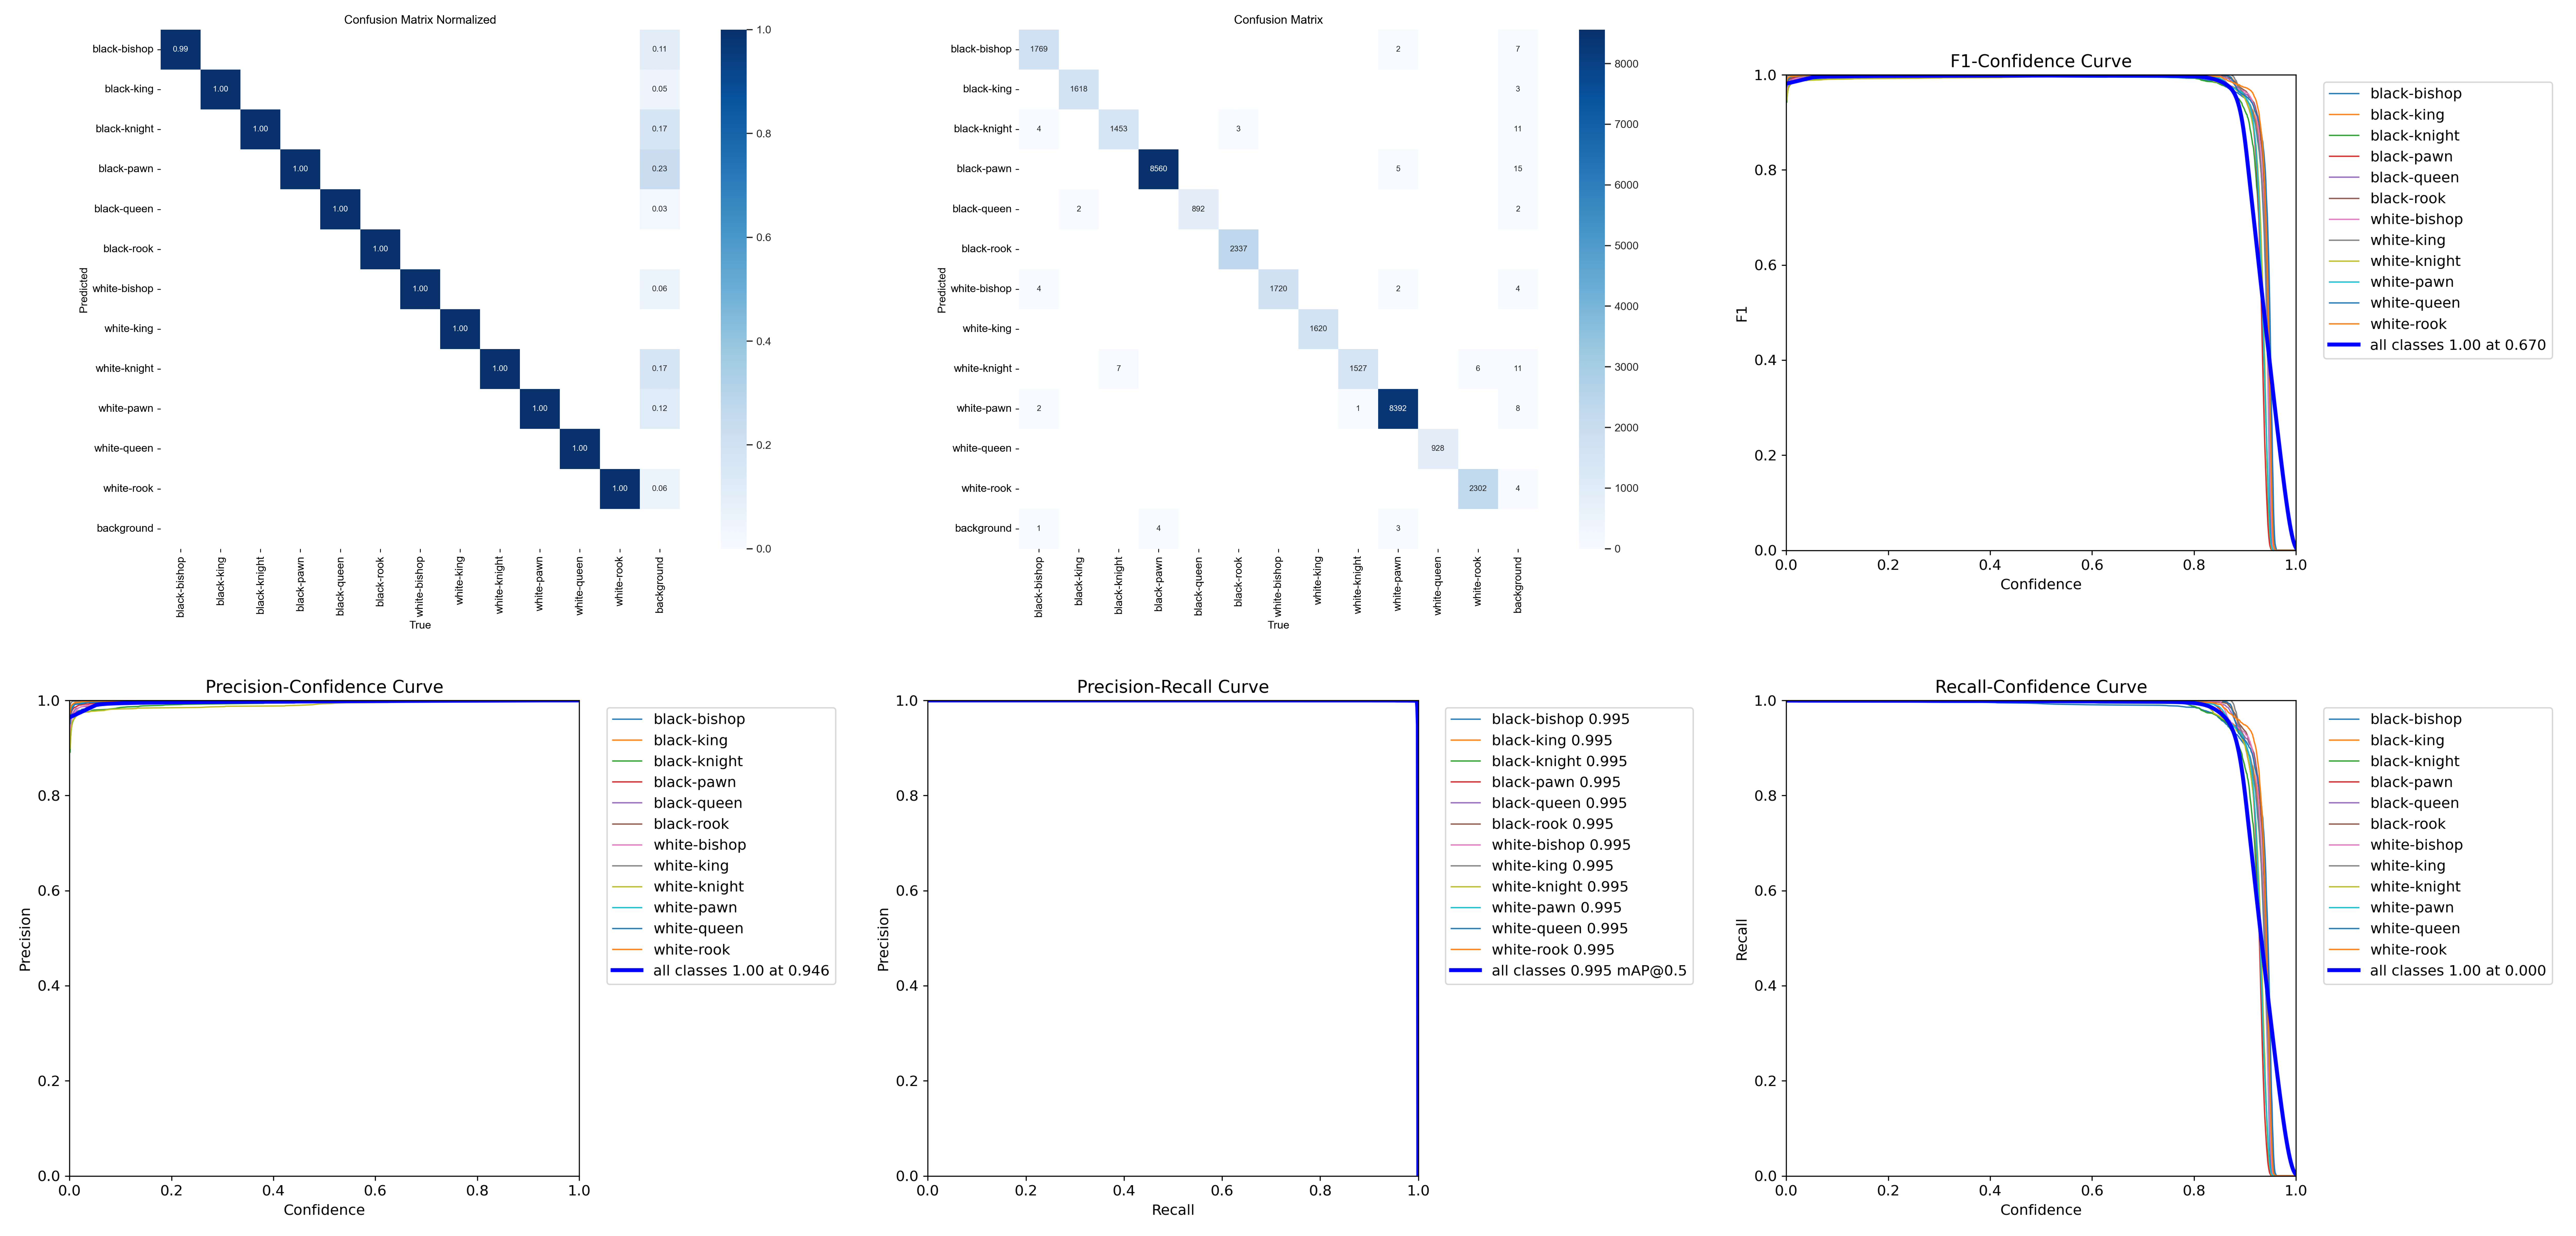

In [ ]:
result_images = ['images/results/confusion_matrix_normalized.png',
                 'images/results/confusion_matrix.png',
                 'images/results/F1_curve.png',
                 'images/results/P_curve.png',
                 'images/results/PR_curve.png',
                 'images/results/R_curve.png',
                ]

n_images = len(result_images)
cols = 3
rows = (n_images + cols - 1) // cols

plt.figure(figsize=(100, 50))

for i, img_path in enumerate(result_images):
    img = mpimg.imread(img_path)
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.axis('off')

plt.tight_layout()
plt.show()

### 4.2 The following images use the trained YOLOv11 model to detect the chess pieces:


image 1/1 /content/drive/MyDrive/Chess Project/notebook/images/OSFHome/osfhome1.png: 448x640 2 black-bishops, 1 black-king, 2 black-knights, 8 black-pawns, 1 black-queen, 2 black-rooks, 2 white-bishops, 1 white-king, 2 white-knights, 7 white-pawns, 1 white-queen, 2 white-rooks, 888.7ms
Speed: 5.7ms preprocess, 888.7ms inference, 2.7ms postprocess per image at shape (1, 3, 448, 640)


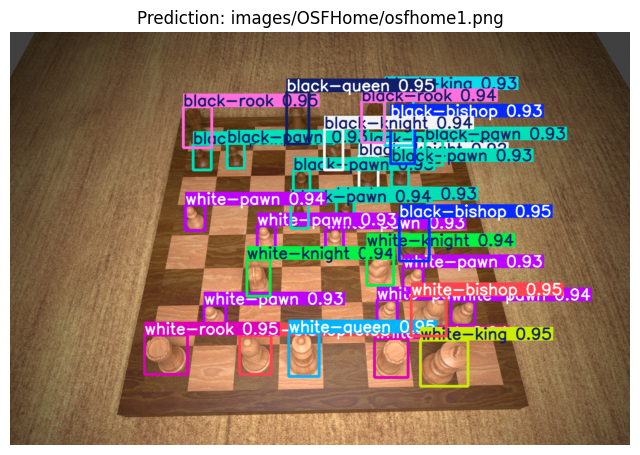


image 1/1 /content/drive/MyDrive/Chess Project/notebook/images/ChessReD/chessred1.jpg: 640x640 2 black-bishops, 1 black-king, 2 black-knights, 7 black-pawns, 1 black-queen, 2 black-rooks, 2 white-bishops, 1 white-king, 2 white-knights, 7 white-pawns, 1 white-queen, 2 white-rooks, 789.8ms
Speed: 21.1ms preprocess, 789.8ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


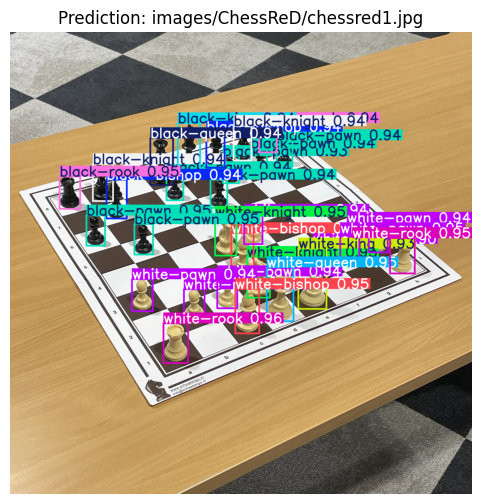


image 1/1 /content/drive/MyDrive/Chess Project/notebook/images/Roboflow/roboflow2.jpg: 640x640 2 black-bishops, 1 black-king, 2 black-knights, 8 black-pawns, 1 black-queen, 2 black-rooks, 2 white-bishops, 1 white-king, 2 white-knights, 8 white-pawns, 1 white-queen, 2 white-rooks, 613.5ms
Speed: 6.8ms preprocess, 613.5ms inference, 2.3ms postprocess per image at shape (1, 3, 640, 640)


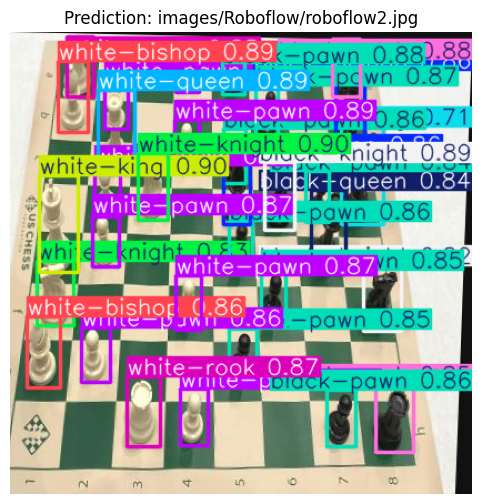

In [ ]:
model = YOLO("best.pt")

sample_images = [
    'images/OSFHome/osfhome1.png',
    'images/ChessReD/chessred1.jpg',
    'images/Roboflow/roboflow2.jpg'
]

for img_path in sample_images:
    results = model.predict(source=img_path, save=False)

    # Get the image with bounding boxes
    annotated_img = results[0].plot()

    # Convert BGR to RGB for proper display
    annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

    # Display using matplotlib
    plt.figure(figsize=(8, 6))
    plt.imshow(annotated_img_rgb)
    plt.axis('off')
    plt.title(f"Prediction: {img_path}")
    plt.show()